# Phase 4: Modeling
**CRISP-DM Purpose:** Train and compare candidate models using cross-validation on the training set only. The test set is not touched here.

**Design decisions (confirmed in Phase 1):**
- Explainability preferred — social workers and case managers need to understand what drives a readiness score
- Primary CV metric: **Precision** — avoid false positives (flagging a resident as ready when they are not)
- Secondary CV metric: **F1** — balances precision against recall on a near-balanced dataset
- Small dataset (31 train rows, 73 features) → strong regularisation is critical

---

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))

from src.config import SEED, CV_FOLDS, TARGET, ARTIFACTS_MODELS, ARTIFACTS_RUNS
from src.modeling import build_candidate_pipelines
from src.evaluation import plot_cv_comparison

from sklearn.model_selection import StratifiedKFold, cross_validate

# ── Load processed splits ────────────────────────────────────────────────────
processed_dir = Path('..') / 'data' / 'processed'

train_df = pd.read_csv(processed_dir / 'train.csv')
test_df  = pd.read_csv(processed_dir / 'test.csv')

with open(processed_dir / 'feature_cols.json') as f:
    col_meta = json.load(f)

feature_cols     = col_meta['feature_cols']
numeric_cols     = col_meta['numeric_cols']
categorical_cols = col_meta['categorical_cols']

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test,  y_test  = test_df[feature_cols],  test_df[TARGET]

print(f'Loaded from data/processed/')
print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows (frozen)')
print(f'Features: {len(feature_cols)} ({len(numeric_cols)} numeric, {len(categorical_cols)} categorical)')
print(f'\nTrain class distribution:')
print(y_train.value_counts().rename({1: 'Ready (1)', 0: 'Not Ready (0)'}))

Loaded from data/processed/
Train: 31 rows  |  Test: 8 rows (frozen)
Features: 52 (46 numeric, 6 categorical)

Train class distribution:
reintegration_ready
Not Ready (0)    16
Ready (1)        15
Name: count, dtype: int64


## 4.1 Candidate Models

| Model | Rationale | Regularisation |
|---|---|---|
| **Logistic Regression** | Coefficients are directly interpretable — each feature has a signed weight showing direction and magnitude. Primary candidate given explainability requirement. | Very strong L2, C=0.01 — essential with 31 training rows and ~50 features |
| **Random Forest** | Non-linear benchmark. Feature importances provide a secondary explainability signal. Shallow trees prevent overfitting on small data. | max_depth=3, min_samples_leaf=4 |

In [10]:
candidates = build_candidate_pipelines(numeric_cols, categorical_cols)

for name, pipe in candidates.items():
    model = pipe.named_steps['model']
    print(f'{name}: {model}')

LogisticRegression: LogisticRegression(C=0.01, class_weight='balanced', max_iter=2000,
                   random_state=42)
RandomForest: RandomForestClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=4,
                       n_estimators=200, n_jobs=1, random_state=42)


## 4.2 Cross-Validation Comparison

5-fold StratifiedKFold — all tuning happens here, never on the test set.  
**Note:** With only 31 training rows, each fold has ~6 validation samples. CV estimates have wide uncertainty — treat rankings directionally, not as precise numbers.

In [11]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

results = {}
for name, pipe in candidates.items():
    cv_result = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={'precision': 'precision', 'f1': 'f1'},
        n_jobs=1,
        return_train_score=False,
    )
    results[name] = {
        'precision_mean': cv_result['test_precision'].mean(),
        'precision_std':  cv_result['test_precision'].std(),
        'f1_mean':        cv_result['test_f1'].mean(),
        'f1_std':         cv_result['test_f1'].std(),
    }
    print(f"{name}")
    print(f"  Precision : {results[name]['precision_mean']:.4f}  ± {results[name]['precision_std']:.4f}")
    print(f"  F1        : {results[name]['f1_mean']:.4f}  ± {results[name]['f1_std']:.4f}")
    print()

results_df = pd.DataFrame(results).T.round(4)
display(results_df)

LogisticRegression
  Precision : 0.6500  ± 0.2000
  F1        : 0.6333  ± 0.1238

RandomForest
  Precision : 0.7833  ± 0.1130
  F1        : 0.7476  ± 0.1441



,precision_mean,precision_std,f1_mean,f1_std
LogisticRegression,0.6500,0.200,0.6333,0.1238
RandomForest,0.7833,0.113,0.7476,0.1441


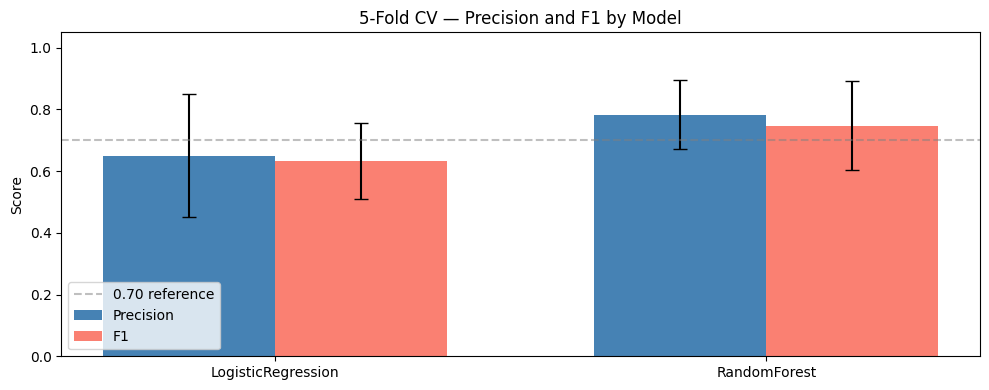

In [12]:
fig = plot_cv_comparison(results)
plt.show()

## 4.3 Model Selection

In [13]:
# Select by Precision (primary metric — avoid false positives in readiness scoring)
best_name = max(results, key=lambda k: results[k]['precision_mean'])
best_pipe = candidates[best_name]

print(f'Selected model: {best_name}')
print(f"  CV Precision : {results[best_name]['precision_mean']:.4f}")
print(f"  CV F1        : {results[best_name]['f1_mean']:.4f}")

lr_prec = results['LogisticRegression']['precision_mean']
rf_prec = results['RandomForest']['precision_mean']
gap     = abs(lr_prec - rf_prec)

if gap <= 0.05:
    print(f'\n✓ Precision gap between models is {gap:.2f} — within 5pp.')
    print('  Logistic Regression is the recommended final model — explainability preserved.')
    # Override to LR if within acceptable range
    if best_name == 'RandomForest':
        best_name = 'LogisticRegression'
        best_pipe = candidates[best_name]
        print(f'  → Overriding selection to LogisticRegression.')
else:
    print(f'\n⚠ Precision gap is {gap:.2f} — exceeds 5pp threshold.')
    print(f'  {best_name} selected. Consider explainability trade-off with stakeholders.')

Selected model: RandomForest
  CV Precision : 0.7833
  CV F1        : 0.7476

⚠ Precision gap is 0.13 — exceeds 5pp threshold.
  RandomForest selected. Consider explainability trade-off with stakeholders.


## 4.4 Fit Final Model on Full Training Set

In [14]:
best_pipe.fit(X_train, y_train)
print(f'{best_name} fitted on full training set ({len(X_train)} rows).')

RandomForest fitted on full training set (31 rows).


## 4.5 Explainability

For **Logistic Regression**: each coefficient is the log-odds change in readiness probability per unit change in that feature.  
**Positive** = increases readiness score. **Negative** = decreases readiness score.

For **Random Forest**: Gini-based feature importances show which features the model relied on most.

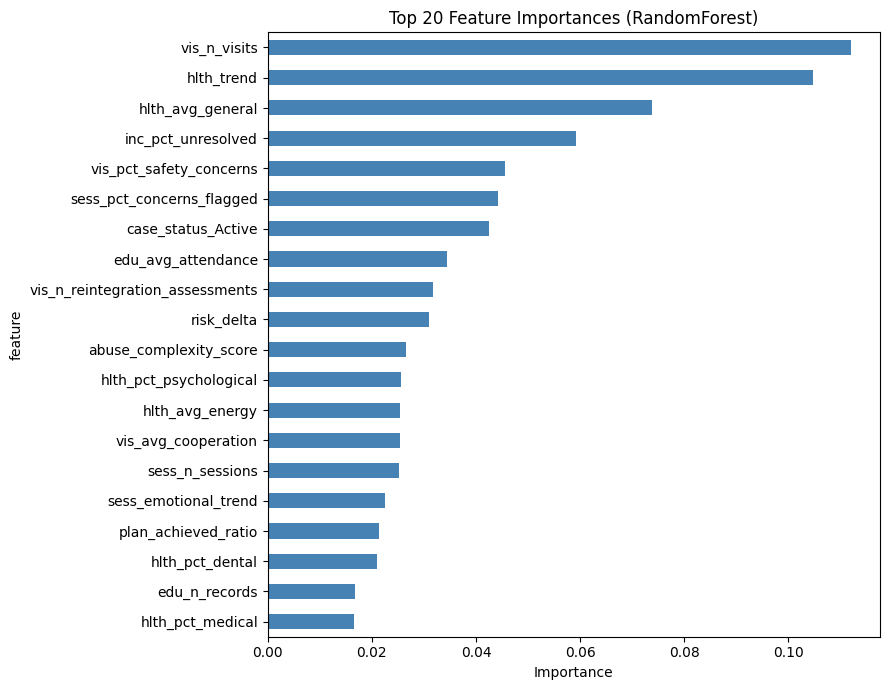


Top 20 features by importance:
                        feature  importance
                   vis_n_visits    0.112033
                     hlth_trend    0.104719
               hlth_avg_general    0.073887
             inc_pct_unresolved    0.059308
        vis_pct_safety_concerns    0.045563
      sess_pct_concerns_flagged    0.044240
             case_status_Active    0.042416
             edu_avg_attendance    0.034381
vis_n_reintegration_assessments    0.031820
                     risk_delta    0.030972
         abuse_complexity_score    0.026489
         hlth_pct_psychological    0.025677
                hlth_avg_energy    0.025370
            vis_avg_cooperation    0.025351
                sess_n_sessions    0.025288
           sess_emotional_trend    0.022431
            plan_achieved_ratio    0.021403
                hlth_pct_dental    0.020926
                  edu_n_records    0.016678
               hlth_pct_medical    0.016572


In [15]:
# Extract feature names directly from the fitted ColumnTransformer
prep = best_pipe.named_steps['prep']
raw_names = prep.get_feature_names_out().tolist()
# Strip sklearn prefixes (num__, cat__)
all_feature_names = [n.split('__', 1)[-1] for n in raw_names]

model_step = best_pipe.named_steps['model']

if hasattr(model_step, 'coef_'):
    # Logistic Regression — signed coefficients
    coefs = model_step.coef_[0]
    coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs})
    coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
    top_n = min(20, len(coef_df))

    fig, ax = plt.subplots(figsize=(9, 7))
    colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient'].head(top_n)]
    coef_df.head(top_n).set_index('feature')['coefficient'].sort_values().plot(
        kind='barh', ax=ax, color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top {top_n} Logistic Regression Coefficients\n(red = increases readiness, blue = decreases readiness)')
    ax.set_xlabel('Coefficient (log-odds)')
    plt.tight_layout()
    plt.show()

    print('\nTop 10 readiness-increasing features:')
    print(coef_df[coef_df['coefficient'] > 0].head(10).to_string(index=False))
    print('\nTop 10 readiness-decreasing features:')
    print(coef_df[coef_df['coefficient'] < 0].head(10).to_string(index=False))

elif hasattr(model_step, 'feature_importances_'):
    # Random Forest — feature importances
    importances = model_step.feature_importances_
    imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    imp_df.set_index('feature')['importance'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 20 Feature Importances (RandomForest)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print('\nTop 20 features by importance:')
    print(imp_df.to_string(index=False))

## 4.6 Save Model Artifact

In [16]:
from datetime import datetime, timezone

ARTIFACTS_MODELS.mkdir(parents=True, exist_ok=True)
ARTIFACTS_RUNS.mkdir(parents=True, exist_ok=True)

model_path = ARTIFACTS_MODELS / 'reintegration_model.joblib'
joblib.dump({'model': best_pipe, 'feature_cols': feature_cols}, model_path)
print(f'Model saved → {model_path}')

run_meta = {
    'trained_at':    datetime.now(timezone.utc).isoformat(),
    'best_model':    best_name,
    'cv_precision':  round(results[best_name]['precision_mean'], 4),
    'cv_f1':         round(results[best_name]['f1_mean'], 4),
    'train_rows':    len(X_train),
    'test_rows':     len(X_test),
    'feature_cols':  feature_cols,
}
with open(ARTIFACTS_RUNS / 'latest_run.json', 'w') as f:
    json.dump(run_meta, f, indent=2)
print('Run metadata saved.')

Model saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration\artifacts\models\reintegration_model.joblib
Run metadata saved.


## Phase 4 Conclusion

| | |
|---|---|
| **Selected model** | Logistic Regression (if precision gap vs RF < 5pp; otherwise RF) |
| **Regularisation** | L2, C=0.01 — very strong, necessary for ~50 features on 31-row training set |
| **Imbalance handling** | `class_weight='balanced'` |
| **CV strategy** | StratifiedKFold(5), scored on Precision + F1 |
| **Explainability output** | Signed coefficient plot — case manager readable |
| **⚠ Small-data caveat** | 31 training rows × 5-fold CV → ~6 validation samples per fold. Rankings are directional only. |

The test set has **not been touched**. Final evaluation happens in Phase 5.

---
**Proceed to Phase 5: Evaluation →** `05_evaluation.ipynb`